# Feature engineering и скоринг бинарного события (Gini/ROC-AUC)

Основной вопрос этой работы: сколько качества даёт целенаправленная работа с признаками и можно ли заменить её автоматикой — featuretools или генерацией признаков языковой моделью. Забегая вперёд, заменить не получилось.

Задача — предсказать бинарный исход события по данным, доступным на ранней стадии, когда часть признаков ещё не наблюдается (на тесте они отсутствуют). Обучающая выборка ~700 000 наблюдений, данные разнесены по пяти таблицам: события, участники, справочник сущностей, временные ряды показателей. В роли данных — обезличенная статистика матчей Dota 2.

Целевая метрика — коэффициент Джини, посчитанный из ROC-AUC как $Gini = |2 \cdot ROCAUC - 1|$. Та же метрика используется как стандарт качества скоринговых моделей в риск-менеджменте, поэтому и постановка, и способ оценки здесь ближе к скорингу, чем к спортивному соревнованию.

Что внутри: обработка пропусков (медиана плюс флаг отсутствия, с разбором альтернативы — предсказывать пропуск отдельной моделью), нормализующие преобразования и квантильная бинаризация, target encoding со сглаживанием, кастомные трансформеры без наследования от sklearn (эмбеддинг состава команды, кумулятивные винрейт и пикрейт без утечки из будущего), агрегации временных рядов — тренд и площадь под кривой методами прямоугольников, трапеций и Симпсона плюс своя функция интегрирования с перекосом веса к началу или концу ряда. В конце — Optuna с персистентным хранилищем экспериментов и feature selection на L1-регуляризации с учётом доли оставленных признаков.

Стек: Python, pandas, scikit-learn, category_encoders, featuretools, Optuna, LightGBM/CatBoost.

---


## Генерация признаков

В этом проекте разбирается генерация признаков и построение модели предсказания исхода матча в киберспортивной дисциплине Dota 2 — командной игре 5 на 5, где команды соревнуются за уничтожение базы соперника.

Задача: предсказать исход матча (победа или поражение) по данным, доступным на ранних стадиях матча — постановка ориентирована именно на матчи, которые едва начались, поэтому часть данных на тестовой выборке отсутствует. Целевая метрика — коэффициент Джини, чтобы избегать вырожденных значений метрики меньше $0.5$:

$$ \text{Gini} = | 2 \cdot \text{ROCAUC} - 1 |$$

In [6]:
from sklearn.metrics import roc_auc_score
from typing import Optional, Callable


def gini(y_true, y_score):
    return abs(2 * roc_auc_score(y_true, y_score) - 1.0)

#### 1.1. Знакомство с данными

В работе используются:

1. Информация о матчах - `matches_df_train.csv`.
2. Информация об игроках - `player_df.csv`.
3. Информация о героях - `Constants.Heroes.csv`.
4. Информация о статистиках матча - `dota_adv.csv`.
5. Тестовые данные - `matches_df_test.csv`.

Первые шаги:

1. Обзор всех таблиц - колонки, ключи для джойна, типы данных.
2. Проверка пропусков, дублей, выбросов.
3. Разбиение данных на трейн и валидацию.
4. Распределение таргета на трейне и валидации.
5. Оценка применимости метрики Джини для этой задачи.

In [8]:
from sklearn.model_selection import train_test_split
import os

matches_train = pd.read_csv("matches_df_train.csv")
matches_test  = pd.read_csv("matches_df_test.csv")
players       = pd.read_csv("player_df.csv")
heroes        = pd.read_csv("Constants.Heroes.csv")
adv_stats     = pd.read_csv("dota_adv.csv")

for name, df in [
    ("matches_train", matches_train),
    ("matches_test", matches_test),
    ("players", players),
    ("heroes", heroes),
    ("adv_stats", adv_stats)
]:
    print(f"\n{name.lower()}")
    print(df.dtypes)


matches_train
match_id        int64
date           object
region          int64
game_mode       int64
duration        int64
radiant_win      bool
dtype: object

matches_test
match_id      int64
date         object
region        int64
game_mode     int64
dtype: object

players
player_slot       int64
account_id        int64
hero_id           int64
kills           float64
deaths          float64
assists         float64
gold            float64
last_hits       float64
denies          float64
gold_per_min    float64
xp_per_min      float64
hero_damage     float64
tower_damage    float64
match_id          int64
dtype: object

heroes
Unnamed: 0             int64
id                     int64
name                  object
primary_attr          object
attack_type           object
roles                 object
img                   object
icon                  object
base_health            int64
base_health_regen    float64
base_mana              int64
base_mana_regen      float64
base_armor      

In [9]:
datasets = {
    "matches_train": matches_train,
    "matches_test": matches_test,
    "players": players,
    "heroes": heroes,
    "adv_stats": adv_stats
}

for name, df in datasets.items():
    print(f"\n {name.lower()}")
    na = df.isna().sum().sort_values(ascending=False)
    print("Пропуски данных в %:")
    print((na[na > 0] / len(df) * 100).round(2))

    print("Дубликатов:", df.duplicated().sum())


 matches_train
Пропуски данных в %:
Series([], dtype: float64)
Дубликатов: 7

 matches_test
Пропуски данных в %:
Series([], dtype: float64)
Дубликатов: 1

 players
Пропуски данных в %:
kills           7.94
deaths          7.94
assists         7.94
gold            7.94
last_hits       7.94
denies          7.94
gold_per_min    7.94
xp_per_min      7.94
hero_damage     7.94
tower_damage    7.94
dtype: float64
Дубликатов: 0

 heroes
Пропуски данных в %:
turn_rate            65.08
base_health_regen     0.79
dtype: float64
Дубликатов: 0

 adv_stats
Пропуски данных в %:
Series([], dtype: float64)
Дубликатов: 12


In [10]:
for name, df in datasets.items():
    print(f"\n{name.lower()}")   
    df.dropna(inplace=True)
    after = len(df)
    print(f"Осталось строк: {after}")


matches_train
Осталось строк: 706880

matches_test
Осталось строк: 60954

players
Осталось строк: 7043331

heroes
Осталось строк: 44

adv_stats
Осталось строк: 767834


In [11]:
matches_train = matches_train.drop_duplicates(subset=["match_id"]).reset_index(drop=True)

matches_test = matches_test.drop_duplicates(subset=["match_id"]).reset_index(drop=True)

adv_stats = adv_stats.drop_duplicates(subset=["match_id"]).reset_index(drop=True)

In [12]:
import ast

matches = matches_train.copy()
players_df = players.copy()
heroes_df = heroes.copy()
adv_df = adv_stats.copy()

matches['date'] = pd.to_datetime(matches['date'], errors='coerce')

for col in ['radiant_gold_adv', 'radiant_exp_adv']:
    adv_df[col] = [
        np.array([int(i) for i in x.strip('[]').split()]) if isinstance(x, str) else np.nan
        for x in adv_df[col]
    ]

    adv_df[f'{col}_final'] = [x[-1] if isinstance(x, np.ndarray) and len(x) > 0 else np.nan for x in adv_df[col]]
    adv_df[f'{col}_mean']  = [np.mean(x) if isinstance(x, np.ndarray) and len(x) > 0 else np.nan for x in adv_df[col]]
    adv_df[f'{col}_max']   = [np.max(x) if isinstance(x, np.ndarray) and len(x) > 0 else np.nan for x in adv_df[col]]


adv_df = adv_df.drop(columns=['radiant_gold_adv', 'radiant_exp_adv'])


heroes_df = heroes_df.rename(columns={'id': 'hero_id'})[
    ['hero_id', 'primary_attr', 'attack_type', 'move_speed', 'base_attack_min', 'base_attack_max']
]


players_heroes = players_df.merge(heroes_df, on='hero_id', how='left')


agg_players = (
    players_heroes.groupby('match_id')
    .agg({
        'kills': ['mean', 'sum', 'max'],
        'deaths': ['mean', 'sum', 'max'],
        'assists': ['mean', 'sum', 'max'],
        'gold_per_min': ['mean', 'sum', 'max'],
        'xp_per_min': ['mean', 'sum', 'max']
    })
)
agg_players.columns = ['_'.join(col).strip() for col in agg_players.columns]
agg_players = agg_players.reset_index()


match_features_df = (
    matches
    .merge(agg_players, on='match_id', how='left')
    .merge(adv_df, on='match_id', how='left')
)

 
print(f"match_features_df shape: {match_features_df.shape}")
print(match_features_df.head())

match_features_df shape: (706870, 27)
     match_id       date  region  game_mode  duration  radiant_win  \
0  1606558457 2024-01-01       3          1        50         True   
1  1533104773 2024-01-01       3          1        86         True   
2  1494396881 2024-01-01       3          1       211         True   
3  1457581060 2024-01-01       3          1       270         True   
4  1590242915 2024-01-01       3         21       318         True   

   kills_mean  kills_sum  kills_max  deaths_mean  ...  gold_per_min_max  \
0         0.1        1.0        1.0          0.1  ...            1145.0   
1         0.2        2.0        2.0          0.2  ...             505.0   
2         0.2        2.0        1.0          0.2  ...             395.0   
3         2.6       26.0       21.0          2.8  ...            2055.0   
4         1.0        2.0        2.0          1.0  ...             467.0   

   xp_per_min_mean  xp_per_min_sum  xp_per_min_max  radiant_gold_adv_final  \
0           

In [13]:
from sklearn.model_selection import train_test_split


X = match_features_df.drop(columns=['radiant_win'])
y = match_features_df['radiant_win'].astype(int)


X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train shape: {X_train.shape}, Validation shape: {X_valid.shape}")
print(f"Train target mean: {y_train.mean():.3f}, Validation target mean: {y_valid.mean():.3f}")

Train shape: (565496, 26), Validation shape: (141374, 26)
Train target mean: 0.513, Validation target mean: 0.513


#### 1.2. Бейзлайн

Поскольку решается задача классификации:

1. Выбор нескольких признаков для базовой модели.
2. Выбор модели, предсказывающей вероятность класса, а не только сам класс.
3. Обучение модели и замер качества.

In [15]:
features = [
    'duration', 'region', 'game_mode',
    'radiant_gold_adv_final', 'radiant_gold_adv_mean', 'radiant_gold_adv_max',
    'radiant_exp_adv_final', 'radiant_exp_adv_mean', 'radiant_exp_adv_max'
]

X = match_features_df[features]
y = match_features_df['radiant_win'].astype(int)

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

df_model = match_features_df[features + ['radiant_win']].dropna().reset_index(drop=True)

X = df_model[features]
y = df_model['radiant_win'].astype(int)


X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, solver='lbfgs'))
])

pipe.fit(X_train, y_train)

y_pred_proba = pipe.predict_proba(X_valid)[:, 1]

roc_auc = roc_auc_score(y_valid, y_pred_proba)
gini = abs(2 * roc_auc - 1)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Gini: {gini:.4f}")

ROC-AUC: 0.7389
Gini: 0.4778


### Разведочный анализ данных

Разведочный анализ разделён на общий обзор и детальный разбор потенциально наиболее важных факторов, с промежуточными выводами по каждому признаку — зашёл он в модель или нет, и почему.

#### 3.1. Пропуски в данных 

Колонка `duration` доступна лишь на обучающих данных, но не на тестовых. Тогда чтобы использовать информацию о длительности матча, сперва эту длительность необходимо как-то достать.

По сути есть несколько возможностей это сделать:

1. Заполнить пропуски на валидационной и тестовой выборках константным значением.
2. Попробовать предсказать значение `duration` при помощи простенькой линейной модели.
3. Добавить отсутствие значения отдельным признаком.

Выбрать подходящий вариант нам поможет информация о распределении `duration`. Подберем наиболее подходящую визуализацию.

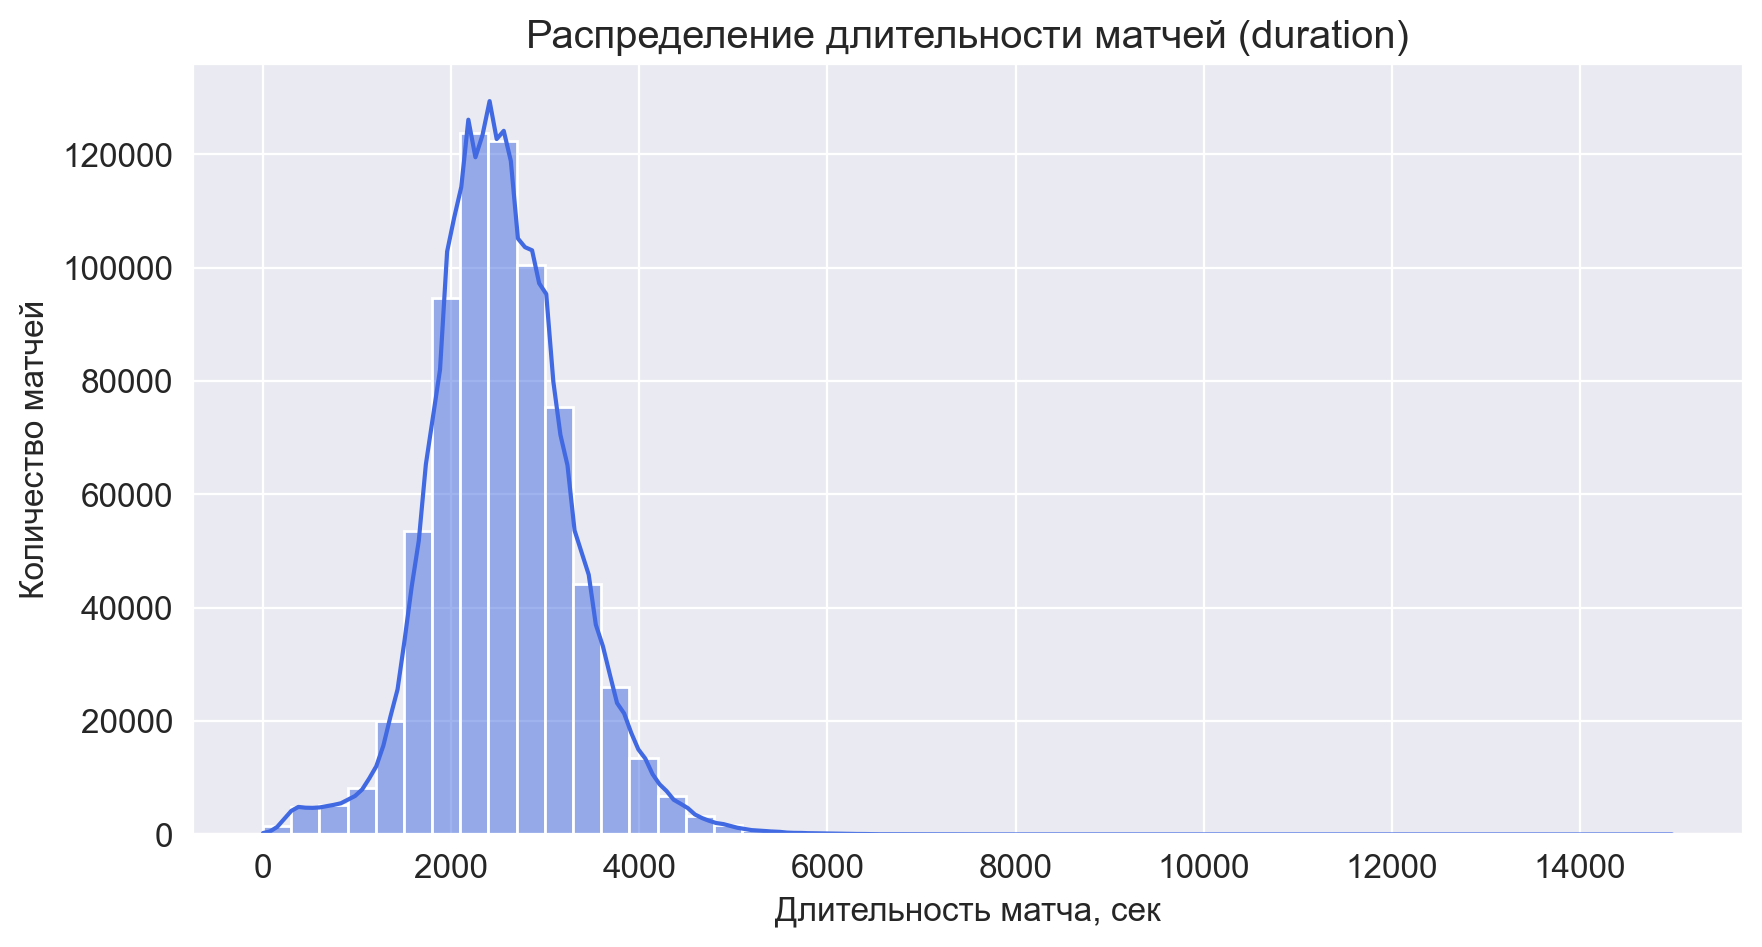

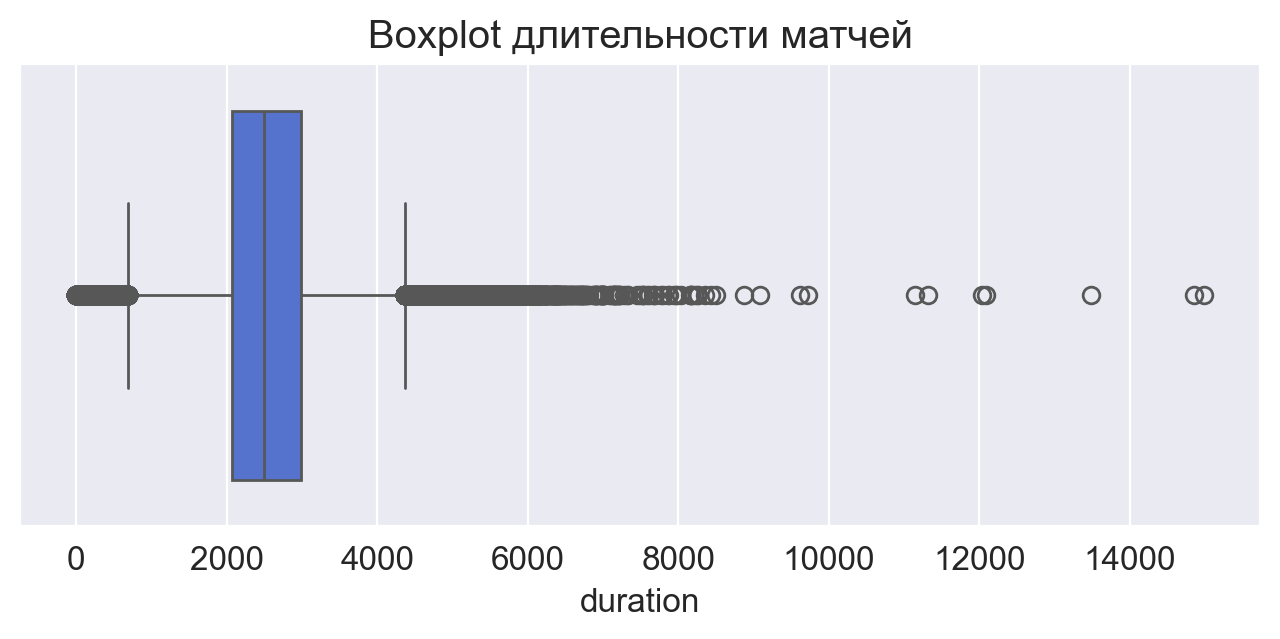

In [19]:
%config InlineBackend.figure_format = 'retina'

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['font.size'] = 12

sns.set_style('darkgrid')

plt.figure(figsize=(10,5))
sns.histplot(matches_train['duration'], bins=50, kde=True, color="royalblue")
plt.title("Распределение длительности матчей (duration)")
plt.xlabel("Длительность матча, сек")
plt.ylabel("Количество матчей")
plt.show()

plt.figure(figsize=(8,3))
sns.boxplot(x=matches_train['duration'], color="royalblue")
plt.title("Boxplot длительности матчей")
plt.show()

In [20]:
matches_train['duration_missing'] = matches_train['duration'].isna().astype(int)
matches_test['duration_missing'] = 1  # во всём тесте duration отсутствует

# заполняем медианой
median_duration = matches_train['duration'].median()
matches_train['duration'] = matches_train['duration'].fillna(median_duration)
matches_test['duration'] = median_duration

print(f"duration заполнен медианой ({median_duration:.0f} сек)")

duration заполнен медианой (2496 сек)


In [21]:
matches_train['duration'].mean()

2536.4686165773055

Была выбрана медиана, ведь она обычно меньше всего влияет на изменение распределения. К тому же добавлен флаг, модель знает что данных о длительности в тесте нет.
- Предсказывать значения длительности матча линейной моделью может быть также хорошей идеей. Если получим низкое качество модели на выходе, то можно будет вернутся к этой идеи.

In [23]:
features_base = [col for col in X_train.columns if col not in ['duration', 'duration_missing']]
features_with_duration = features_base + [col for col in ['duration', 'duration_missing'] if col in X_train.columns]

def train_and_eval(features, name):
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression())
    ])
    
    model.fit(X_train[features], y_train)
    y_pred_proba = model.predict_proba(X_valid[features])[:, 1]
    
    roc_auc = roc_auc_score(y_valid, y_pred_proba)
    gini = 2 * roc_auc - 1
    print(f"{name}: ROC-AUC={roc_auc:.4f}, Gini={gini:.4f}")
    return gini

print("Сравнение моделей:")
gini_base = train_and_eval(features_base, "Без duration")
gini_with_dur = train_and_eval(features_with_duration, "С duration")

improvement = gini_with_dur - gini_base
print(f"\nИзменение Gini после добавления duration: {improvement:+.4f}")

Сравнение моделей:
Без duration: ROC-AUC=0.7377, Gini=0.4753
С duration: ROC-AUC=0.7389, Gini=0.4778

Изменение Gini после добавления duration: +0.0025


#### 3.2. Простейшие преобразования

Признак, который на первый взгляд должен быть полезным, на практике иногда оказывается бесполезным — причины разные: признак действительно нерелевантен, в данных есть ошибка, либо признак неправильно подготовлен. При L2-регуляризации признаки желательно распределять близко к нормальному, хотя на практике это не всегда достижимо.

Далее:

1. Анализ смещения, среднего и хвостов распределения признака `duration`.
2. Три способа сделать признак `duration` ближе к нормальному распределению (обозначим длительность матча как $y$):

$$y \rightarrow \log y, \sqrt{y}, \frac{1}{y}$$

3. Сравнение того, как каждое преобразование влияет на распределение признака, и добавление всех трёх трансформаций вместе с признаком $\exp{\log{y}}$ (снова `duration`).

- В распределении duration наблюдается правосторонняя асимметрия 
- Правый хвост тяжелее левого (короткий матчей почти нет, а длинные встречаются достаточно редко, чтобы повлиять на распределение
- среднее: 2536 секунд (42.2 минуты / матч)

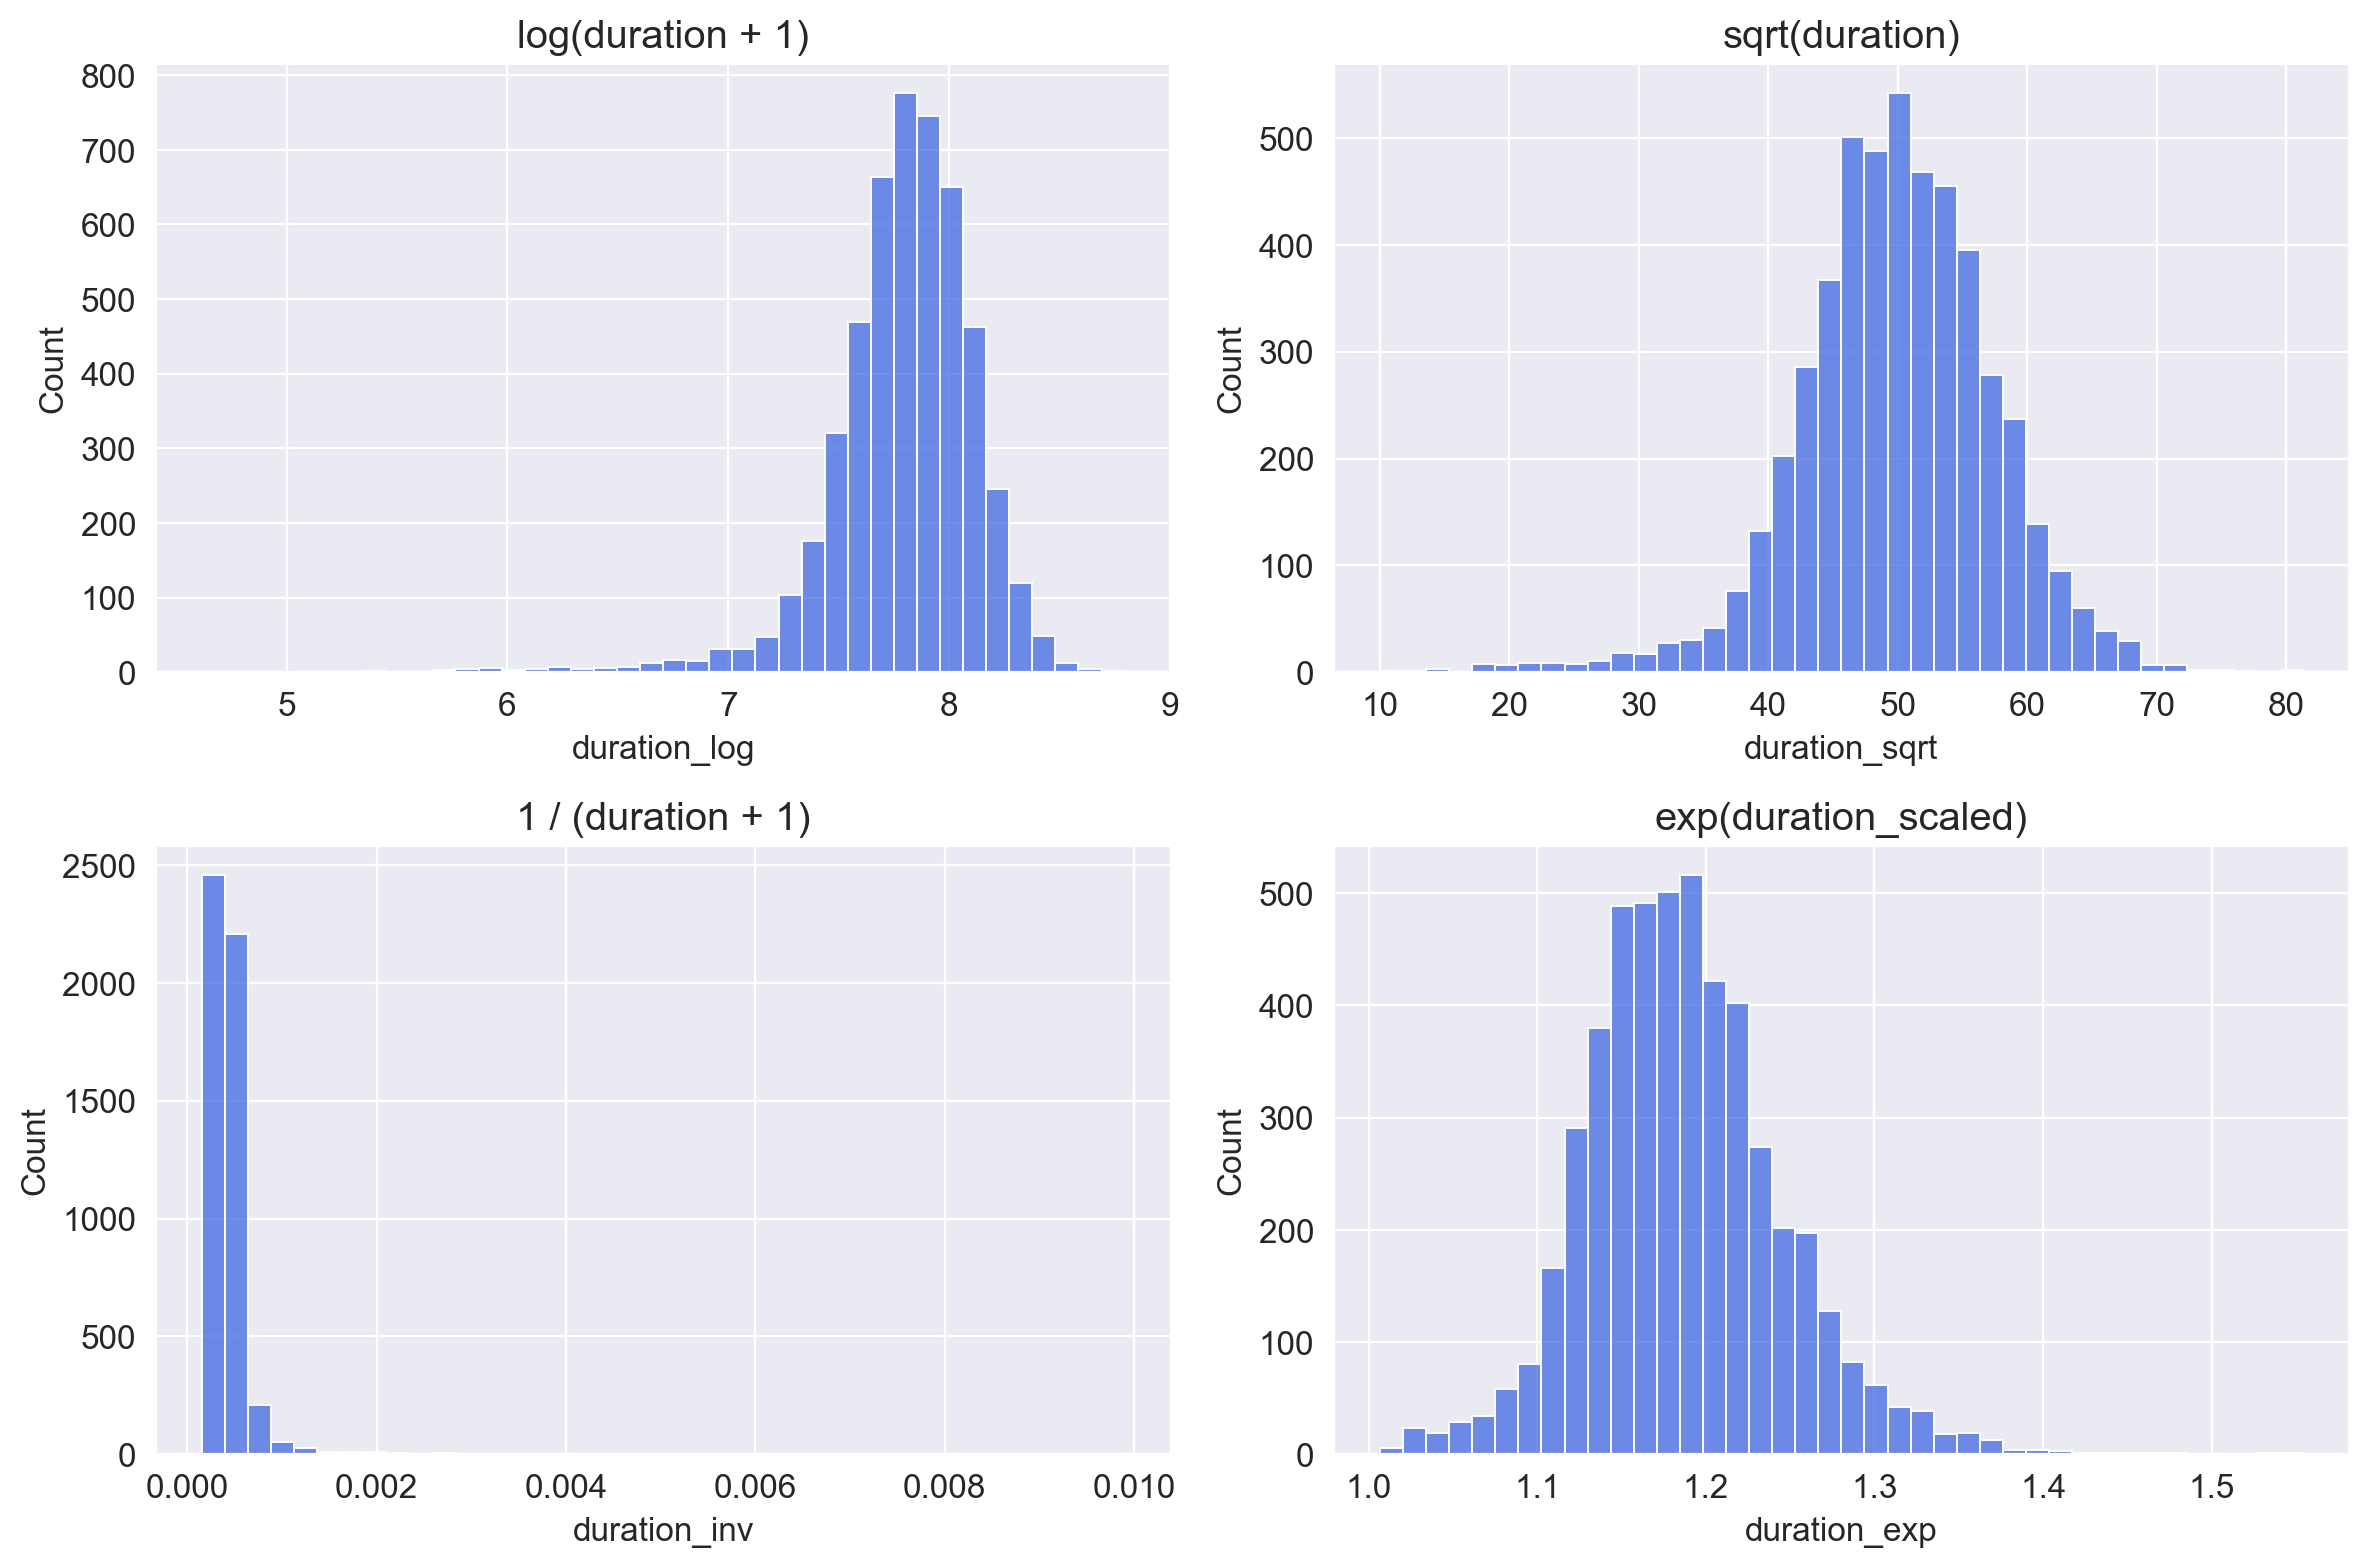

In [26]:
dur = matches_train['duration'].dropna()

matches_train['duration_log'] = np.log1p(dur)
matches_train['duration_sqrt'] = np.sqrt(dur)
matches_train['duration_inv'] = 1 / (dur + 1)
matches_train['duration_exp'] = np.exp(dur / dur.max())

for col in ['duration_log', 'duration_sqrt', 'duration_inv', 'duration_exp']:
    matches_train[col] = matches_train[col].replace([np.inf, -np.inf], np.nan)

sample_df = matches_train.sample(5000, random_state=42)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
cols = ['duration_log', 'duration_sqrt', 'duration_inv', 'duration_exp']
titles = ['log(duration + 1)', 'sqrt(duration)', '1 / (duration + 1)', 'exp(duration_scaled)']

for i, col in enumerate(cols):
    sns.histplot(sample_df[col].dropna(), kde=False, ax=axes[i], bins=40, color = "royalblue")
    axes[i].set_title(titles[i])

plt.tight_layout()
plt.show()

In [27]:
match_features_df = match_features_df.copy()

duration = match_features_df['duration'].fillna(match_features_df['duration'].median())

match_features_df['duration_log'] = np.log1p(duration)
match_features_df['duration_sqrt'] = np.sqrt(duration)
match_features_df['duration_inv'] = 1 / (duration + 1)
match_features_df['duration_explogy'] = np.exp(np.log1p(duration) / np.log1p(duration).max())

In [28]:
duration_features = ['duration', 'duration_log', 'duration_sqrt', 'duration_inv', 'duration_explogy']
features = [
    col for col in match_features_df.columns
    if col not in ['radiant_win', 'date']  
]

df_model = match_features_df[features + ['radiant_win']].dropna().reset_index(drop=True)
X = df_model[features]
y = df_model['radiant_win'].astype(int)

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify = y
)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])

pipe.fit(X_train, y_train)

y_pred_proba = pipe.predict_proba(X_valid)[:, 1]
roc_auc = roc_auc_score(y_valid, y_pred_proba)
gini = abs(2 * roc_auc - 1)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Gini: {gini:.4f}")

ROC-AUC: 0.7422
Gini: 0.4843


#### 3.3. Регионы

Уровень игроков может отличаться между регионами, и распределение таргета по регионам может отличаться даже для простых признаков.

1. Распределение категорий признака `region`.
2. Проверка, отличается ли распределение целевой переменной по разным категориям `region`.
3. Кодирование признака библиотекой [category_encoders](https://contrib.scikit-learn.org/category_encoders).

Уникальные регионы: [ 3  4 12  9  6 11  2 10  5  1  8  7]


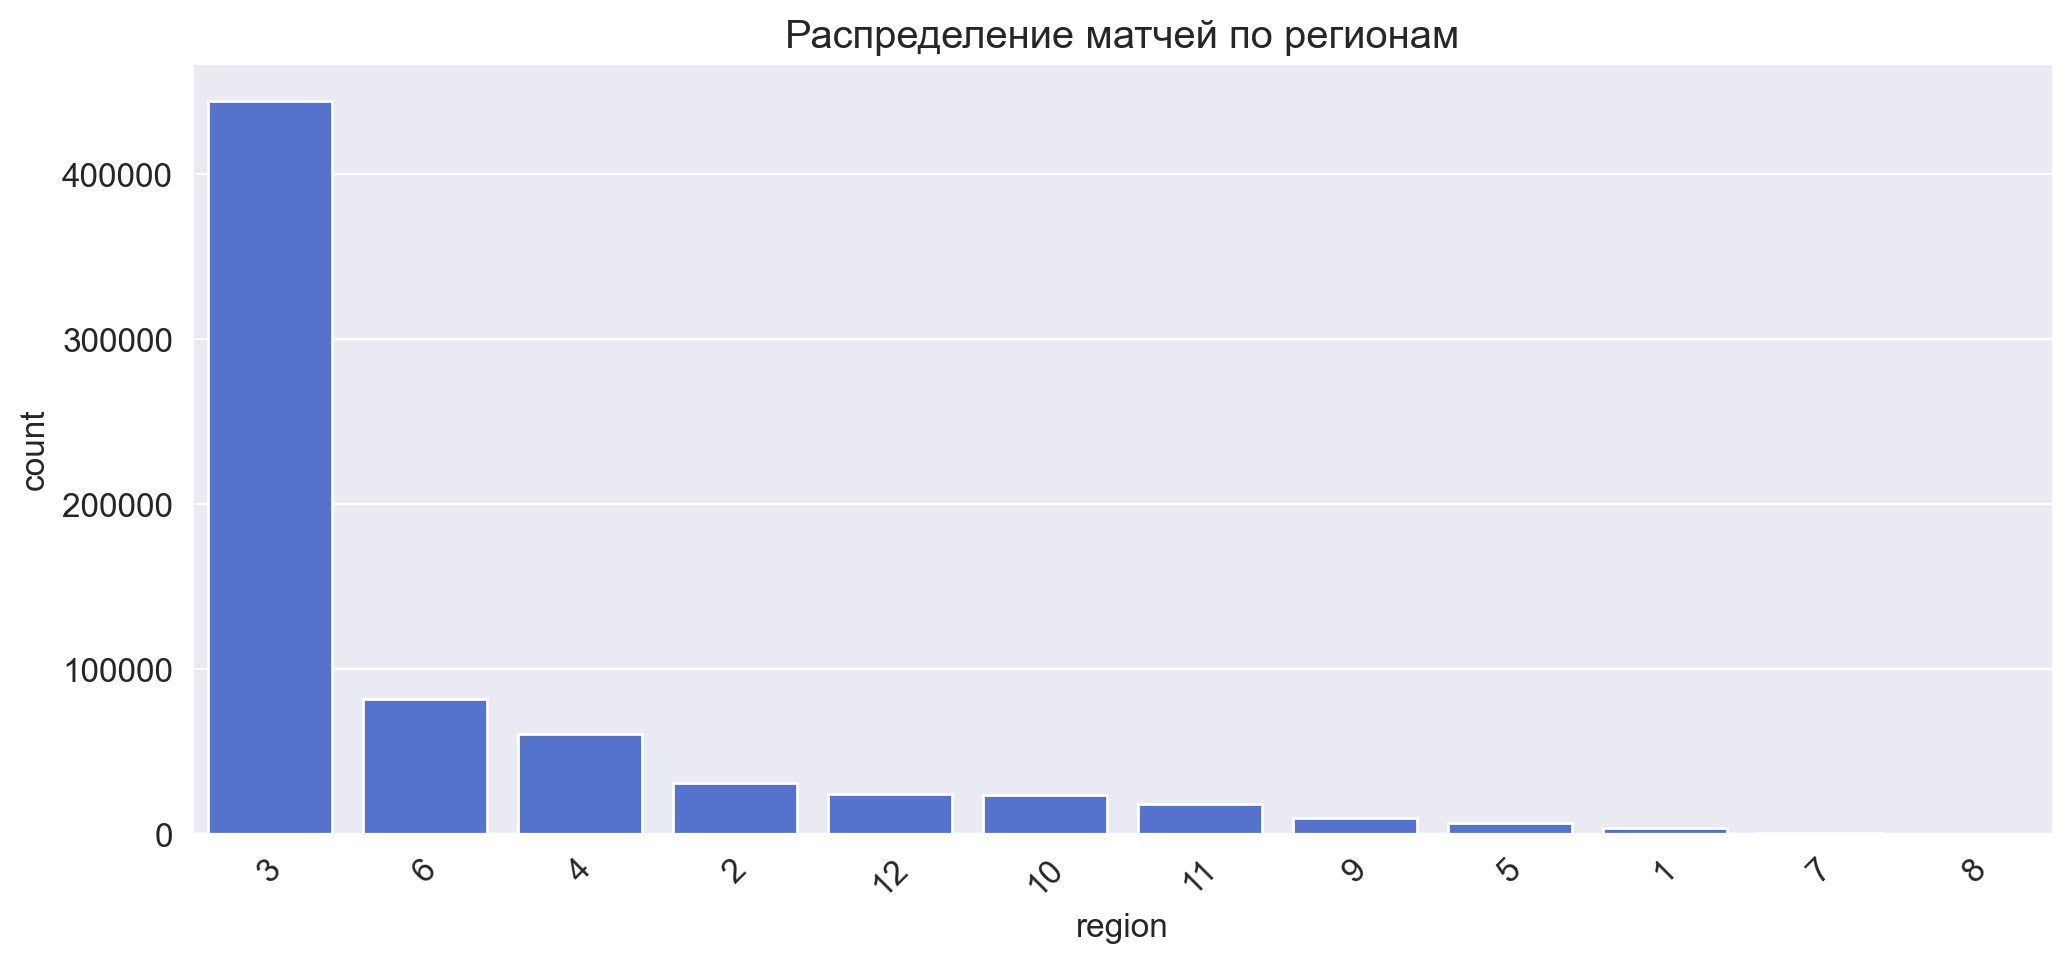

In [30]:
print("Уникальные регионы:", match_features_df['region'].unique())

plt.figure(figsize=(12,5))
sns.countplot(x = 'region', data = match_features_df, order = match_features_df['region'].value_counts().index, color = "royalblue")
plt.title('Распределение матчей по регионам')
plt.xticks(rotation=45)
plt.show()

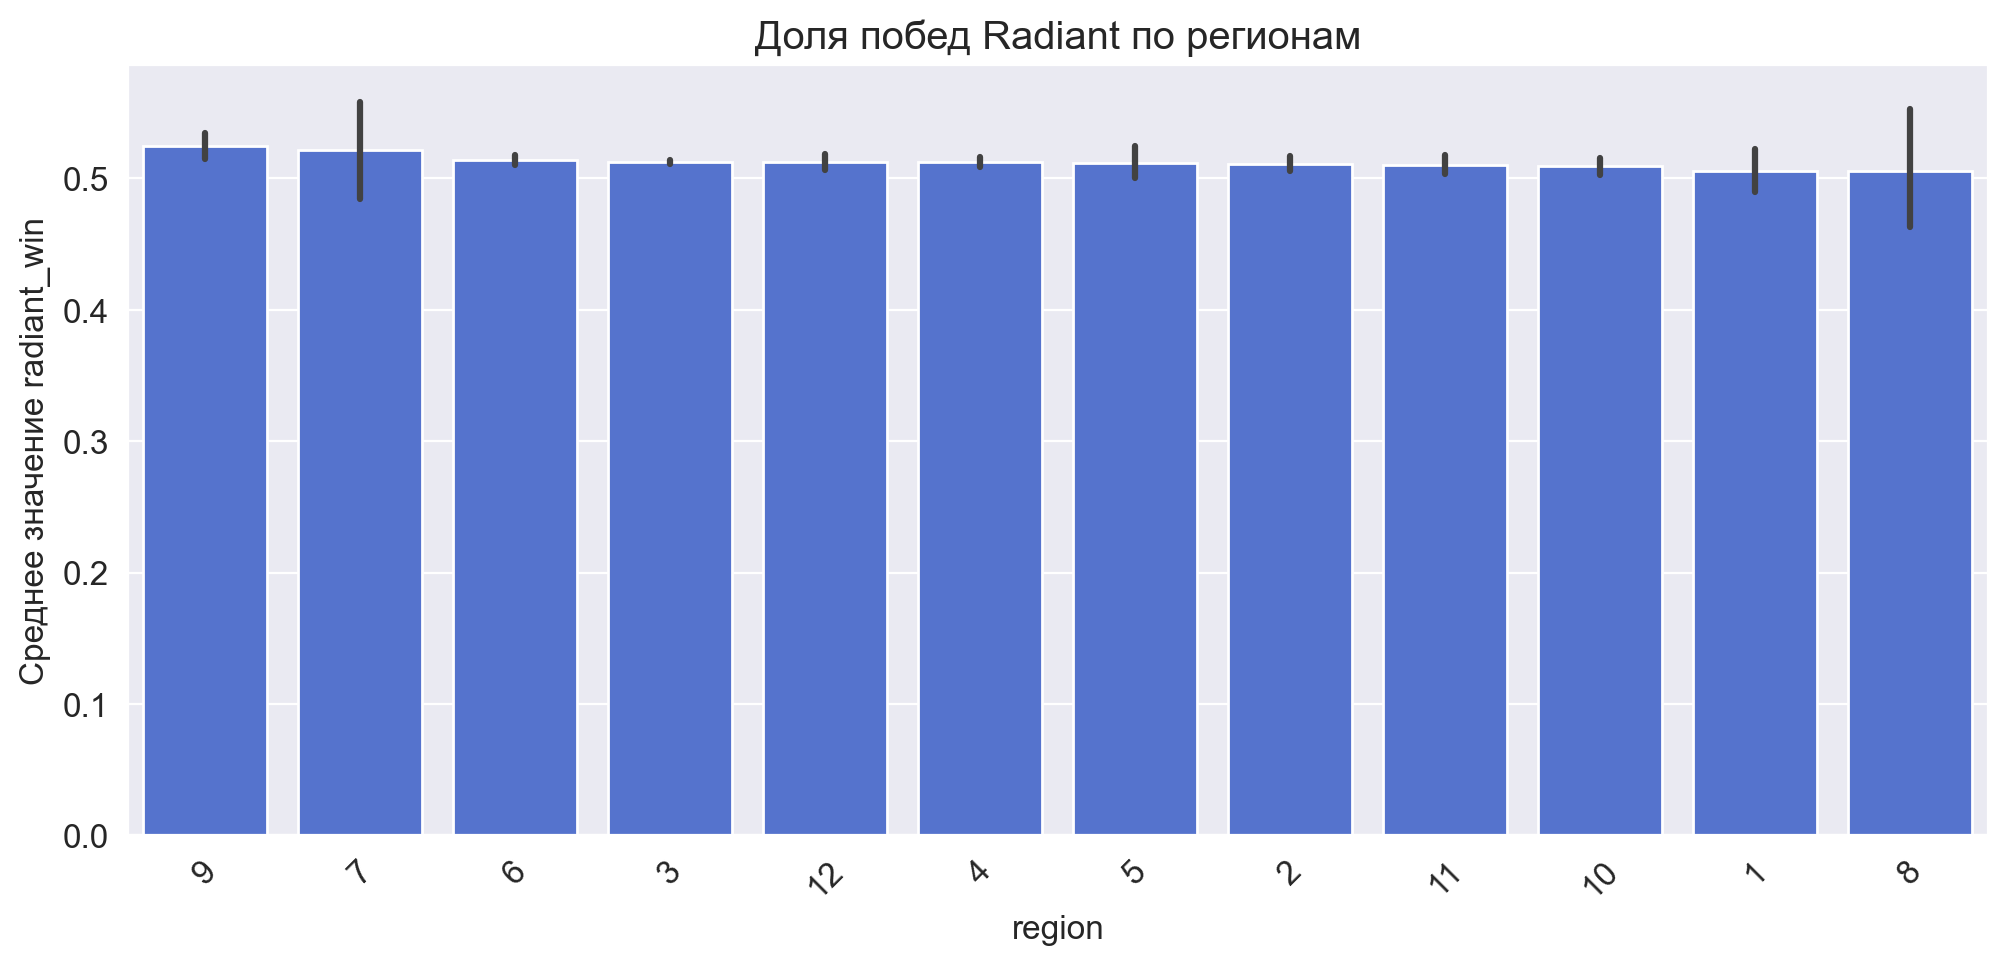

In [31]:
plt.figure(figsize=(12,5))
sns.barplot(
    x = 'region',
    y = 'radiant_win',
    data = match_features_df,
    order = match_features_df.groupby('region')['radiant_win'].mean().sort_values(ascending=False).index,
    color = "royalblue"
)
plt.title('Доля побед Radiant по регионам')
plt.xticks(rotation=45)
plt.ylabel('Среднее значение radiant_win')
plt.show()

- Регион 3 доминирует по количеству матчей — значит, OneHotEncoder создаст перекошенную матрицу (одна категория будет слишком влиятельна).
Средние значения radiant_win все таки различаются по регионам — скорее всего, таргетная информация в признаке есть.

- Мне понравился TargetEncoder. Он заменяет каждую категорию на среднее значение целевой переменной (radiant_win) для этой категории, при этом применяет сглаживание, чтобы не было переобучения на редких регионах.

In [33]:
import category_encoders as ce

match_features_encoded = match_features_df.copy()

encoder = ce.TargetEncoder(cols=['region'], smoothing=0.3)

X = match_features_encoded.drop(columns=['radiant_win', 'date'])
y = match_features_encoded['radiant_win'].astype(int)

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

te = ce.TargetEncoder(cols=['region'], smoothing=0.3)
te.fit(X_train[['region']], y_train)

X_train_te = X_train.copy()
X_valid_te = X_valid.copy()
X_train_te['region_encoded'] = te.transform(X_train[['region']]).values
X_valid_te['region_encoded'] = te.transform(X_valid[['region']]).values

print(pd.DataFrame({'region': X_train['region'].head(10).values, 'region_encoded': X_train_te['region_encoded'].head(10).values}))

   region  region_encoded
0       3        0.512723
1       6        0.512936
2       3        0.512723
3       3        0.512723
4       3        0.512723
5       3        0.512723
6       3        0.512723
7       3        0.512723
8       6        0.512936
9       6        0.512936


In [34]:
from sklearn.impute import SimpleImputer

features = X_train_te.columns.tolist()

pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])

pipe.fit(X_train_te, y_train)

y_pred_proba = pipe.predict_proba(X_valid_te)[:, 1]
roc_auc = roc_auc_score(y_valid, y_pred_proba)
gini = abs(2 * roc_auc - 1)

print(" Результаты модели с кодированным 'region':")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Gini: {gini:.4f}")

 Результаты модели с кодированным 'region':
ROC-AUC: 0.6311
Gini: 0.2622


#### 3.4. Даты

Игра регулярно обновляется — меняются механики и баланс, поэтому модель может вести себя по-разному в зависимости от даты. Отслеживание временных признаков часто помогает учитывать такие изменения.

1. Временные признаки, которые можно получить из даты матча.
2. Значимые даты, которые могли повлиять на результаты матчей.
3. Способ кодирования таких признаков.

In [36]:
match_features_encoded['date'] = pd.to_datetime(match_features_encoded['date'], errors='coerce')

match_features_encoded['year'] = match_features_encoded['date'].dt.year
match_features_encoded['month'] = match_features_encoded['date'].dt.month
match_features_encoded['day_of_week'] = match_features_encoded['date'].dt.dayofweek  
match_features_encoded['hour'] = match_features_encoded['date'].dt.hour
match_features_encoded['is_weekend'] = match_features_encoded['day_of_week'].isin([5, 6]).astype(int)

match_features_encoded['is_new_year'] = match_features_encoded['date'].dt.strftime('%m-%d').isin(['12-31', '01-01']).astype(int)

match_features_encoded[['date', 'year', 'month', 'day_of_week', 'is_weekend', 'is_new_year']].head()

,date,year,month,day_of_week,is_weekend,is_new_year
0,2024-01-01,2024,1,0,0,1
1,2024-01-01,2024,1,0,0,1
2,2024-01-01,2024,1,0,0,1
3,2024-01-01,2024,1,0,0,1
4,2024-01-01,2024,1,0,0,1


In [38]:
df_model = match_features_encoded.dropna(subset=['radiant_win']).copy()
X_temp = df_model.drop(columns=['radiant_win', 'date'])
y_temp = df_model['radiant_win'].astype(int)

X_train_temp, X_valid_temp, y_train_temp, y_valid_temp = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp
)

day_encoder = ce.TargetEncoder(cols=['day_of_week'], smoothing=0.3)
day_encoder.fit(X_train_temp[['day_of_week']], y_train_temp)

X_train_temp['day_of_week_encoded'] = day_encoder.transform(X_train_temp[['day_of_week']]).values
X_valid_temp['day_of_week_encoded'] = day_encoder.transform(X_valid_temp[['day_of_week']]).values

X_train_temp = X_train_temp.drop(columns=['day_of_week'])
X_valid_temp = X_valid_temp.drop(columns=['day_of_week'])

pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=2000))
])

pipe.fit(X_train_temp, y_train_temp)

y_pred_proba = pipe.predict_proba(X_valid_temp)[:, 1]
roc_auc = roc_auc_score(y_valid_temp, y_pred_proba)
gini = abs(2 * roc_auc - 1)

print("Результаты модели:")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Gini: {gini:.4f}")

Результаты модели:
ROC-AUC: 0.7633
Gini: 0.5266


- информация оказалось очень полезной для модели, что было ожидаемо.
- признаки закодированы как числовые, для облегечения работы логрега.

#### 3.5. Бинаризация

Отдельный признак иногда настолько важен или нелинейно связан с таргетом, что одного веса в линейной модели недостаточно для его описания — тогда помогает бинаризация: разбиение распределения признака на непересекающиеся бины с кодированием каждого бина отдельной категорией.

1. Выбор вещественного признака, подходящего для бинаризации.
2. Бинаризация (равномерная сетка, квантильная сетка и т.д.).
3. Оценка эффекта.

In [41]:
from sklearn.preprocessing import KBinsDiscretizer

df_bin = match_features_encoded.copy()

feature_to_bin = 'duration'

df_bin_model = df_bin.dropna(subset=['radiant_win']).copy()
X_bin = df_bin_model.drop(columns=['radiant_win', 'date'])
y_bin = df_bin_model['radiant_win'].astype(int)

X_train_bin, X_valid_bin, y_train_bin, y_valid_bin = train_test_split(
    X_bin, y_bin, test_size=0.2, random_state=42, stratify=y_bin
)

binner = KBinsDiscretizer(
    n_bins=4,
    encode='onehot-dense',
    strategy='quantile',
    quantile_method='averaged_inverted_cdf'
)

binner.fit(X_train_bin[[feature_to_bin]])

binned_train = binner.transform(X_train_bin[[feature_to_bin]])
binned_valid = binner.transform(X_valid_bin[[feature_to_bin]])

bin_cols = [f"{feature_to_bin}_bin_{i}" for i in range(binned_train.shape[1])]
binned_train_df = pd.DataFrame(binned_train, columns=bin_cols, index=X_train_bin.index)
binned_valid_df = pd.DataFrame(binned_valid, columns=bin_cols, index=X_valid_bin.index)

X_train_bin = pd.concat([X_train_bin, binned_train_df], axis=1)
X_valid_bin = pd.concat([X_valid_bin, binned_valid_df], axis=1)

print("Бины по duration (train):")
print(pd.qcut(X_train_bin['duration'], q=4).value_counts())

X_train_bin[bin_cols + ['duration']].head()

Бины по duration (train):
duration
(2495.0, 2983.0]     141470
(-0.001, 2063.0]     141402
(2063.0, 2495.0]     141399
(2983.0, 14979.0]    141225
Name: count, dtype: int64


,duration_bin_0,duration_bin_1,duration_bin_2,duration_bin_3,duration
525600,0.0,0.0,1.0,0.0,2900
354283,0.0,1.0,0.0,0.0,2089
405500,0.0,0.0,1.0,0.0,2782
440666,0.0,1.0,0.0,0.0,2350
97663,0.0,1.0,0.0,0.0,2315


In [42]:
pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  
    ('scaler', StandardScaler(with_mean=False)),
    ('model', LogisticRegression(max_iter=2000, solver='liblinear'))
])

pipe.fit(X_train_bin, y_train_bin)

y_pred_proba = pipe.predict_proba(X_valid_bin)[:, 1]
roc_auc = roc_auc_score(y_valid_bin, y_pred_proba)
gini = abs(2 * roc_auc - 1)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Gini: {gini:.4f}")

ROC-AUC: 0.7635
Gini: 0.5270


- Качество стало лучше на 0.0004 по gini
- Выбрали именно квантильную сетку из-за тяжелого хвоста duration, ведь такая сетка имеет одинаковое количество наблюдений в каждом бине, в отличие от равномерной

### 4. Эмбеддинги

Исход матча напрямую зависит от выбранных героев (их более 100, и все они разные). Для их представления используются эмбеддинги — они дают доступ к операциям в векторном пространстве (поиск соседей, расстояние между векторами и т.д.). Ниже — простейший способ их получения через прямое кодирование категорий.

#### 4.1. Эмбеддер героев

В таблице `player_df.csv` указаны все герои, участвовавшие в матче. Каждый матч кодируется вектором вида:

| match_id | match_embedding |
| --- | --- |
| 228 | 1 0 0 -1 -1 0 0 |

где `match_embedding` — вектор матча, каждый элемент которого равен 1, если герой в команде Radiant, и -1, если в команде Dire (аналог `OneHotEncoder`, но не идентичный).

1. Трансформер оформлен в виде класса.
2. Параметр `n_heroes` позволяет учитывать наличие как одного героя, так и сочетаний нескольких.
3. Трансформер корректно определяет принадлежность игрока команде.
4. Трансформер корректно применяется к трейну и валидации.

Трансформер написан с нуля, без использования [TransformerMixin](https://scikit-learn.org/stable/modules/generated/sklearn.base.TransformerMixin.html) и готовых реализаций.

In [46]:
from collections import Counter

In [47]:
class HeroesEmbedder:

    def __init__(self, n_heroes = None, match_col = 'match_id', hero_col = 'hero_id', slot_col = 'player_slot'):
        self.n_heroes = n_heroes
        self.match_col = match_col
        self.hero_col = hero_col
        self.slot_col = slot_col

    def fit(self, X, y = None):
        heroes = X[self.hero_col].astype(int)
        counts = Counter(heroes)

        if self.n_heroes is None or self.n_heroes >= len(counts):
            self.hero_list_ = sorted(counts.keys())
        else:
            self.hero_list_ = [h for h, _ in counts.most_common(self.n_heroes)]
            self.hero_list_ = sorted(self.hero_list_)

        self.hero_to_index_ = {h: i for i, h in enumerate(self.hero_list_)}
        return self

    def transform(self, X, y = None):
        df = X[[self.match_col, self.hero_col, self.slot_col]].copy()
        df[self.hero_col] = df[self.hero_col].astype(int)
        df[self.slot_col] = df[self.slot_col].astype(int)

        match_ids = sorted(df[self.match_col].unique())
        match_to_row = {mid: i for i, mid in enumerate(match_ids)}

        mat = np.zeros((len(match_ids), len(self.hero_list_)), dtype=np.int8)

        for row in df.itertuples(index=False):
            mid = getattr(row, self.match_col)
            hid = getattr(row, self.hero_col)
            slot = getattr(row, self.slot_col)

            if hid in self.hero_to_index_:
                side = 1 if slot < 128 else -1
                r = match_to_row[mid]
                c = self.hero_to_index_[hid]
                mat[r, c] = side

        col_names = [f'hero_{hid}' for hid in self.hero_list_]
        result = pd.DataFrame(mat, columns=col_names)
        result.insert(0, self.match_col, match_ids)
        return result

    
    def fit_transform(self, X, y = None):
        self.fit(X, y)
        return self.transform(X)

Логика проверки корректности эмбеддера:

1) Для каждого матча горизонтальная сумма должна быть 0, то есть ровно 5 героев со стороны Radiant и 5 — со стороны Dire (отклонения проверяются отдельно, например, из-за игроков, вышедших по ходу игры).
2) Для каждого матча значений '1' и '-1' должно быть ровно по 5, у всех игроков должен быть уникальный `id`.

In [49]:
embedder = HeroesEmbedder(n_heroes=None)
embeds = embedder.fit_transform(players_df)

In [50]:
hero_cols = [c for c in embeds.columns if c.startswith('hero_')]

sum_check = embeds[hero_cols].sum(axis=1)
wrong = sum_check[sum_check != 0]

wrong.head()

6      1
55    -1
243   -1
246   -1
515   -1
dtype: int64

In [51]:
ones = (embeds[hero_cols] == 1).sum(axis=1)
minus = (embeds[hero_cols] == -1).sum(axis=1)

wrong_players = embeds[(ones != 5) | (minus != 5)]
wrong_players.head()

,match_id,hero_0,hero_1,hero_2,hero_3,hero_4,hero_5,hero_6,hero_7,hero_8,...,hero_102,hero_103,hero_104,hero_105,hero_106,hero_107,hero_109,hero_110,hero_111,hero_112
6,668058463,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
55,1181392470,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
127,1191880243,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
130,1192002226,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
131,1192039520,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [52]:
dups = []
for mid, grp in players_df.groupby('match_id'):
    if grp['hero_id'].nunique() != len(grp):
        dups.append(mid)
        
dups[:5]

[1181392470, 1195471977, 1195505088, 1197373218, 1202617636]

In [53]:
counts = players_df.groupby("match_id")["hero_id"].count()

unique_heroes = players_df.groupby("match_id")["hero_id"].nunique()

valid_match_ids = counts[(counts == 10) & (unique_heroes == 10)].index

valid_df = players_df[players_df["match_id"].isin(valid_match_ids)]

In [54]:
valid_df.head(3)

,player_slot,account_id,hero_id,kills,deaths,assists,gold,last_hits,denies,gold_per_min,xp_per_min,hero_damage,tower_damage,match_id
0,130,10111871,5,3.0,8.0,15.0,2971.0,55.0,3.0,291.0,390.0,7431.0,146.0,1411590681
1,130,43341844,3,3.0,9.0,3.0,1245.0,25.0,3.0,238.0,346.0,4187.0,34.0,1388958799
2,130,72157343,53,9.0,6.0,20.0,4544.0,226.0,1.0,583.0,704.0,9406.0,2375.0,1587246664


In [55]:
valid_df_with_date = valid_df.merge(
    matches_train[['match_id', 'date']], 
    on='match_id', 
    how='left'
)
valid_df_with_date['date'] = pd.to_datetime(valid_df_with_date['date'], errors='coerce')


cutoff_date_players = valid_df_with_date['date'].quantile(0.8)
train_mask_players = valid_df_with_date['date'] <= cutoff_date_players
valid_mask_players = valid_df_with_date['date'] > cutoff_date_players

players_train = valid_df_with_date[train_mask_players].copy()
players_valid = valid_df_with_date[valid_mask_players].copy()

In [56]:
embedder = HeroesEmbedder(n_heroes=None)
embedder.fit(players_train)
embeds_train = embedder.transform(players_train)
embeds_valid = embedder.transform(players_valid)


embeds_combined = pd.concat([embeds_train, embeds_valid], ignore_index=True)

KeyboardInterrupt: 

In [ ]:
hero_cols = [c for c in embeds_combined.columns if c.startswith("hero_")]

bad_sum = (embeds_combined[hero_cols].sum(axis=1) != 0).sum()
bad_count = (((embeds_combined[hero_cols] == 1).sum(axis=1) != 5) |
             ((embeds_combined[hero_cols] == -1).sum(axis=1) != 5)).sum()

print("Плохих сумм:", bad_sum)
print("Плохих по количеству игроков:", bad_count)

Присоединим эти данные к обучающей и валидационной выборке, и обучим модель.

In [ ]:
df_with_embeds = match_features_encoded.merge(embeds_combined, on='match_id', how='inner')

_df = df_with_embeds.dropna(subset=['date']).copy()
cutoff = _df['date'].quantile(0.8)
train_mask = _df['date'] <= cutoff
valid_mask = _df['date'] > cutoff

X_train_embeds = _df.loc[train_mask].drop(columns=['radiant_win', 'date'])
y_train_embeds = _df.loc[train_mask, 'radiant_win'].astype(int)
X_valid_embeds = _df.loc[valid_mask].drop(columns=['radiant_win', 'date'])
y_valid_embeds = _df.loc[valid_mask, 'radiant_win'].astype(int)

pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=2000))
])

pipe.fit(X_train_embeds, y_train_embeds)

y_pred_proba = pipe.predict_proba(X_valid_embeds)[:, 1]
roc_auc = roc_auc_score(y_valid_embeds, y_pred_proba)
gini = abs(2 * roc_auc - 1)

print("Результаты модели:")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Gini: {gini:.4f}")

#### 4.2. Эмбеддер винрейта

Помимо присутствия героев полезна статистика их побед: если герой выигрывает в большинстве игр, это повышает шансы команды. Такой признак дополняет эмбеддер героев информацией о силе персонажа, которую тот не учитывает.

Чем лучше получается декомпозировать тот или иной признак, тем лучше, ведь улучшается обобщающая способность модели. Иными словами, шанс на победу определенного героя, или пары-тройки-четверки героев, определяется не только тем, как часто они побеждают, но их как часто их берут.

Тогда имеет смысл такой трансформер:

| match_id | wincount_embedding | pickcount_embedding |
| --- | --- | --- |
| 228 | 1 0 0 0 1 0 0 | 1 0 0 0 1 0 0 |
| 322 | 0.5 0 0 0 1 0 0 | 2 0 0 0 2 0 0 |
| 1337| 0.33 0 0 1 0.5 0 0 | 3 0 0 1 3 0 0 |
| ... | ... | ... |

1. Трансформер оформим в виде класса.
2. Трансформер будет подсчитывать кумулятивное число побед (`wincount_HERO`) и кумулятивное число матчей (`pickcount_HERO`) для каждого героя на тренировочной выборке и средний винрейт, средний пикрейт по герою на валидационной выборке (средние будем собирать в методе `fit`).
3. Если героя в матче нет, его винрейт не интересен, поэтому элементы эмбеддинга там будут 0.
4. Трансформер все еще может работать для связок героев, поэтому параметр `n_heroes` оставялем нетронутым.

In [ ]:
matches_train.columns.tolist()

In [ ]:
players_df2 = players_df.copy()

players_df2 = players_df2.merge(
    matches_train[['match_id', 'date', 'radiant_win']],
    on = 'match_id',
    how = 'left'
)

players_df2 = players_df2.dropna(subset=['radiant_win'])

players_df2['radiant_win'] = players_df2['radiant_win'].astype(int)

players_df2 = players_df2.sort_values('date')

print(players_df2.shape)
print(players_df2['radiant_win'].value_counts())

In [ ]:
class WinrateEmbedder:

    def __init__(self, n_heroes = None,
                 match_col = 'match_id', hero_col = 'hero_id',
                 win_col = 'radiant_win', slot_col = 'player_slot',
                 time_col = 'date'):
        self.n_heroes = n_heroes
        self.match_col = match_col
        self.hero_col = hero_col
        self.win_col = win_col
        self.slot_col = slot_col
        self.time_col = time_col

    def fit(self, X, y=None):
        heroes = X[self.hero_col].astype(int)
        pick_counts = heroes.value_counts()

        if self.n_heroes is None or self.n_heroes >= len(pick_counts):
            self.hero_list_ = sorted(pick_counts.index)
        else:
            top = pick_counts.sort_values(ascending=False).head(self.n_heroes).index
            self.hero_list_ = sorted(list(top))

        return self

    def transform(self, X, y=None):
        df = X[[self.match_col, self.hero_col, self.slot_col, self.win_col, self.time_col]].copy()
        df[self.hero_col] = df[self.hero_col].astype(int)

        df["is_radiant"] = (df[self.slot_col] < 128).astype(int)
        df["player_win"] = (df["is_radiant"] == df[self.win_col]).astype(int)

        df = df.sort_values(self.time_col)

        match_ids = df[self.match_col].unique().tolist()
        match_to_row = {mid: i for i, mid in enumerate(match_ids)}
        hero_index = {h: i for i, h in enumerate(self.hero_list_)}

        M, H = len(match_ids), len(self.hero_list_)
        pick_mat = np.zeros((M, H))
        winrate_mat = np.zeros((M, H))

        pick_count = {h: 0 for h in self.hero_list_}
        win_count = {h: 0 for h in self.hero_list_}

        for row in df.itertuples(index=False):
            hid = getattr(row, self.hero_col)
            mid = getattr(row, self.match_col)

            if hid not in hero_index:
                continue

            pick_count[hid] += 1
            win_count[hid] += getattr(row, "player_win")

            r = match_to_row[mid]
            c = hero_index[hid]

            pick_mat[r, c] = pick_count[hid]
            wr = win_count[hid] / pick_count[hid]
            winrate_mat[r, c] = wr

        pick_cols = [f"pickcount_{hid}" for hid in self.hero_list_]
        win_cols = [f"winrate_{hid}" for hid in self.hero_list_]

        result = pd.concat([
            pd.DataFrame({self.match_col: match_ids}),
            pd.DataFrame(pick_mat, columns=pick_cols),
            pd.DataFrame(winrate_mat, columns=win_cols)
        ], axis=1)

        return result

    def fit_transform(self, X, y=None):
        return self.fit(X, y).transform(X)

Как проверить корректность эмбеддера:

1) `pickcount` и `wincount` для каждого героя должны быть неубывающими, когда датафрейм отсортирован по дате.
2) Для каждого матча ненулевых значений в обоих эмбеддингах должно быть не более 10.

In [ ]:
players_df2['date'] = pd.to_datetime(players_df2['date'], errors='coerce')

cutoff_date_wr = players_df2['date'].quantile(0.8)

train_mask_wr = players_df2['date'] <= cutoff_date_wr
valid_mask_wr = players_df2['date'] > cutoff_date_wr

players_df2_train = players_df2[train_mask_wr].copy()
players_df2_valid = players_df2[valid_mask_wr].copy()

In [ ]:
wr_embedder = WinrateEmbedder(n_heroes=None)
wr_embedder.fit(players_df2_train)
wr_embeds_train = wr_embedder.transform(players_df2_train)
wr_embeds_valid = wr_embedder.transform(players_df2_valid)

wr_embeds = pd.concat([wr_embeds_train, wr_embeds_valid], ignore_index=True)

In [ ]:
pick_cols = [c for c in wr_embeds.columns if c.startswith('pickcount_')]
win_cols  = [c for c in wr_embeds.columns if c.startswith('winrate_')]

wr_embeds['nonzero_pick'] = (wr_embeds[pick_cols] > 0).sum(axis=1)
wr_embeds['nonzero_win']  = (wr_embeds[win_cols]  > 0).sum(axis=1)

bad_pick = wr_embeds[wr_embeds['nonzero_pick'] > 10]
bad_win  = wr_embeds[wr_embeds['nonzero_win']  > 10]

print(f"Матчей с >10 ненулевых в pickcount: {len(bad_pick)}")
print(f"Матчей с >10 ненулевых в winrate: {len(bad_win)}")


In [ ]:
wr_embeds = wr_embeds.drop(columns=["nonzero_pick", "nonzero_win"], errors="ignore")

In [ ]:
df_embeds = df_with_embeds.merge(wr_embeds, on='match_id', how='inner')

_df_wr = df_embeds.dropna(subset=['date']).copy()
cutoff_wr = _df_wr['date'].quantile(0.8)
train_mask_wr = _df_wr['date'] <= cutoff_wr
valid_mask_wr = _df_wr['date'] > cutoff_wr

X_train_wr = _df_wr.loc[train_mask_wr].drop(columns=['radiant_win', 'date'])
y_train_wr = _df_wr.loc[train_mask_wr, 'radiant_win'].astype(int)
X_valid_wr = _df_wr.loc[valid_mask_wr].drop(columns=['radiant_win', 'date'])
y_valid_wr = _df_wr.loc[valid_mask_wr, 'radiant_win'].astype(int)

pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=2000))
])

pipe.fit(X_train_wr, y_train_wr)

y_pred_proba = pipe.predict_proba(X_valid_wr)[:, 1]
roc_auc = roc_auc_score(y_valid_wr, y_pred_proba)
gini = abs(2 * roc_auc - 1)

print("Результаты модели:")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Gini: {gini:.4f}")

### 5. Агрегации

Идея — свернуть массив данных до одного или нескольких чисел, которые его описывают. Эффективная, но громоздкая техника: для $n$ признаков, $m$ агрегаций и $d$ размера окна агрегации получается порядка $n \cdot m \cdot d$ признаков.

#### 5.1. Статистики матча

Статистики матча (`_adv`-колонки) фиксируют динамику золота и опыта команд на протяжении игры — по интуиции, чем больше разница в этих показателях, тем выше шансы на победу; это и проверяется далее.

Положительное значение соответствует преимуществу Radiant, отрицательное — преимуществу Dire. Каждое значение колонки `..._adv` содержит массив — фактически, распределение с рядом параметров, которые нужно извлечь.

1. Обзор колонок с суффиксом `_adv`.
2. Проверка на пропуски и краевые случаи (в частности, что в каждом массиве ровно 16 значений).
3. Расчёт статистик распределения.
4. Анализ полезности через heatmap корреляции посчитанных признаков с целевой переменной и между собой.

In [ ]:
adv_stats.head(10)

In [ ]:
adv_stats = pd.read_csv("dota_adv.csv")

adv_cols = [c for c in adv_stats.columns if c.endswith("_adv")]

for col in adv_cols:
    cleaned = []
    for v in adv_stats[col]:
        s = v.strip()[1:-1].strip()
        nums = s.split()
        arr = np.array([float(x) for x in nums])
        cleaned.append(arr)

    adv_stats[col] = cleaned

In [ ]:
good_idx = []  

for i, row in adv_stats.iterrows():
    ok = True
    for col in adv_cols:
        v = row[col]

        if isinstance(v, (list, np.ndarray)):
            if len(v) != 16:
                ok = False
                break

    if ok:
        good_idx.append(i)

adv_stats_clean = adv_stats.loc[good_idx].reset_index(drop=True)

print("Всего строк:", len(adv_stats))
print("Корректных строк:", len(adv_stats_clean))

In [ ]:
stat_cols = []

for col in adv_cols:
    mean_list = []
    std_list = []
    max_list = []
    min_list = []
    slope_list = []   
    
    for arr in adv_stats_clean[col]:
        arr = np.array(arr)

        mean_list.append(arr.mean())
        std_list.append(arr.std())
        max_list.append(arr.max())
        min_list.append(arr.min())
        slope_list.append(arr[-1] - arr[0])

    adv_stats_clean[col + "_mean"] = mean_list
    adv_stats_clean[col + "_std"]  = std_list
    adv_stats_clean[col + "_max"]  = max_list
    adv_stats_clean[col + "_min"]  = min_list
    adv_stats_clean[col + "_slope"] = slope_list

    stat_cols += [col + "_mean", col + "_std", col + "_max", col + "_min", col + "_slope"]

In [ ]:
stats_with_target = adv_stats_clean.merge(
    df_embeds[['match_id', 'radiant_win']],
    on='match_id',
    how='inner'
)

num_cols = [c for c in stats_with_target.columns if stats_with_target[c].dtype != 'object']
corr = stats_with_target[num_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(
    corr[['radiant_win']].sort_values('radiant_win', ascending=False),
    annot=True, fmt=".3f", cmap="coolwarm", vmin=-1, vmax=1
)
plt.title("Корреляция статистик с целевой переменной")
plt.show()

# Корреляция между признаками
plt.figure(figsize=(10, 6))
sns.heatmap(
    corr,
    annot=False,
    cmap="coolwarm",
    vmin=-1, vmax=1
)
plt.title("Корреляция между статистиками")
plt.show()

опыт - самый полезный фактор 

средний перевес по золоту почти не связан с победой

In [ ]:
adv = adv_stats_clean.copy()

def calc_mean(arr):
    return np.mean(arr)

def calc_std(arr):
    return np.std(arr)

def calc_min(arr):
    return np.min(arr)

def calc_max(arr):
    return np.max(arr)

adv["radiant_exp_adv_mean"]  = adv["radiant_exp_adv"].apply(calc_mean)
adv["radiant_exp_adv_std"]   = adv["radiant_exp_adv"].apply(calc_std)
adv["radiant_exp_adv_min"]   = adv["radiant_exp_adv"].apply(calc_min)
adv["radiant_exp_adv_max"]   = adv["radiant_exp_adv"].apply(calc_max)

df_adv = adv[["match_id",
              "radiant_exp_adv_mean",
              "radiant_exp_adv_std",
              "radiant_exp_adv_min",
              "radiant_exp_adv_max"]]

df_final = df_embeds.merge(df_adv, on="match_id", how="inner")

feature_cols = [
    "radiant_exp_adv_mean",
    "radiant_exp_adv_std",
    "radiant_exp_adv_min",
    "radiant_exp_adv_max",
]

X = df_final.drop(columns=["radiant_win", 'date'])
y = df_final["radiant_win"].astype(int)

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=2000)),
])

pipe.fit(X_train, y_train)

y_pred_proba = pipe.predict_proba(X_valid)[:, 1]
roc_auc = roc_auc_score(y_valid, y_pred_proba)
gini = abs(2 * roc_auc - 1)

print("Результаты модели:")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Gini: {gini:.4f}")

#### 5.2. Тренд

Более сложная агрегация — тренд в графиках преимущества: гипотеза в том, что отставание команды в первые 15 минут может быть сигналом камбэка в оставшиеся ~50 минут матча.

1. Трансформер, принимающий на вход функцию агрегации.
2. Выделение тренда для обоих массивов `_adv` разными функциями агрегации, сравнение методов.
3. Добавление соответствующих признаков.
4. Проверка корреляции признака с таргетом.

In [ ]:
class TrendExtractor:

    def __init__(self, agg_func: Callable = None):
        self.agg_func = agg_func

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        result = pd.DataFrame()

        for col in X.columns:
            if col.endswith("_adv"):
                new_col = col + "_trend"
                result[new_col] = X[col].apply(self.agg_func)

        return result
        
def diff_first_last(arr):
    arr = np.array(arr)
    return arr[-1] - arr[0]
    
def slope(arr):
    arr = np.array(arr)
    x = np.arange(len(arr))
    return np.polyfit(x, arr, 1)[0]

In [ ]:
trend_diff  = TrendExtractor(diff_first_last).transform(adv_stats_clean)
trend_slope = TrendExtractor(slope).transform(adv_stats_clean)

trend_diff["match_id"] = adv_stats_clean["match_id"]
trend_slope["match_id"] = adv_stats_clean["match_id"]

trend_diff = trend_diff.rename(columns={
    "radiant_gold_adv_trend": "gold_trend_diff",
    "radiant_exp_adv_trend": "exp_trend_diff"
})

trend_slope = trend_slope.rename(columns={
    "radiant_gold_adv_trend": "gold_trend_slope",
    "radiant_exp_adv_trend": "exp_trend_slope"
})

df_trends = trend_diff.merge(trend_slope, on="match_id", how="inner")

df1 = df_trends.merge(
    df_final[["match_id", "radiant_win"]],
    on="match_id", how="inner"
)

cols = [
    "gold_trend_diff", "exp_trend_diff",
    "gold_trend_slope", "exp_trend_slope",
    "radiant_win"
]

trend_corr = df1[cols].corr()["radiant_win"].sort_values(ascending=False)
print(trend_corr)

In [ ]:
df_model1 = df_final.merge(df_trends[[
    "match_id",
    "exp_trend_diff",
    "exp_trend_slope",
]], on="match_id", how="inner")

X = df_model1.drop(columns=["radiant_win", 'date'])
y = df_model1["radiant_win"].astype(int)

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=2000)),
])

pipe.fit(X_train, y_train)

y_pred_proba = pipe.predict_proba(X_valid)[:, 1]
roc_auc = roc_auc_score(y_valid, y_pred_proba)
gini = abs(2 * roc_auc - 1)

print("Результаты модели:")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Gini: {gini:.4f}")

#### 5.3. Площадь под кривой и взаимодействие признаков

Признаки из предыдущих пунктов учитывали информацию либо по оси x, либо по оси y, но не обе сразу. Один из способов учесть обе — комбинирование признаков (например, перемножение или сборка кортежа категориальных признаков); для эмбеддингов и базового EDA это несложно, а для агрегаций — нет.

Площадь под кривой в зависимости от метода расчёта обладает разными свойствами: например, метод левых прямоугольников придаёт больший вес графикам, растущим в начале.

1. Трансформер, принимающий на вход функцию интегрирования.
2. Расчёт площади для обоих массивов `_adv` разными методами (прямоугольников, трапеций, Симпсона).
3. Добавление признаков.
4. Анализ того, что важнее — преимущество в начале или в конце матча, включая кастомную функцию интегрирования с большим весом одному из хвостов.
5. Оценка изменения качества модели.

In [ ]:
class AUCExtractor:

    def __init__(self, agg_func: Callable = None):
        self.agg_func = agg_func

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        result = pd.DataFrame()
        ids = X["match_id"].values

        gold_auc = []
        exp_auc = []

        for arr_gold, arr_exp in zip(X["radiant_gold_adv"], X["radiant_exp_adv"]):
            gold_auc.append(self.agg_func(arr_gold))
            exp_auc.append(self.agg_func(arr_exp))

        result["match_id"] = ids
        result["gold_auc"] = gold_auc
        result["exp_auc"] = exp_auc
        return result

def auc_trap(arr):
    return np.trapz(arr)
    
def auc_right_weight(arr):
    x = np.arange(len(arr))
    weights = x / x.max()    
    return np.sum(arr * weights)

In [ ]:
auc_trap_df = AUCExtractor(auc_trap).transform(adv_stats_clean)
auc_weight_df = AUCExtractor(auc_right_weight).transform(adv_stats_clean)

auc_trap_df = auc_trap_df.rename(columns={
    "gold_auc": "gold_auc_trap",
    "exp_auc": "exp_auc_trap"
})

auc_weight_df = auc_weight_df.rename(columns={
    "gold_auc": "gold_auc_weight",
    "exp_auc": "exp_auc_weight"
})

df_auc = (
    auc_trap_df
    .merge(auc_weight_df, on="match_id", how="inner")
)

df_auc = df_auc.merge(
    df_final[["match_id", "radiant_win"]],
    on="match_id",
    how="inner"
)

cols = [
    "gold_auc_trap", "exp_auc_trap",
    "gold_auc_weight", "exp_auc_weight",
    "radiant_win"
]

corr_auc = df_auc[cols].corr()["radiant_win"].sort_values(ascending=False)
print(corr_auc)

преимущество вначале важнее

In [ ]:
df_model2 = df_model1.merge(
    df_auc[[
        "match_id",
        "exp_auc_trap",
        "exp_auc_weight"
    ]],
    on="match_id",
    how="inner"
)

X = df_model2.drop(columns=["radiant_win", 'date'])
y = df_model2["radiant_win"].astype(int)

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=2000)),
])

pipe.fit(X_train, y_train)

y_pred_proba = pipe.predict_proba(X_valid)[:, 1]
roc_auc = roc_auc_score(y_valid, y_pred_proba)
gini = abs(2 * roc_auc - 1)

print("Результаты модели:")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Gini: {gini:.4f}")

### 6. Сравнение с автоматическим feature engineering

#### 6.1. Автогенерация признаков

1. Библиотека [`featuretools`](https://featuretools.alteryx.com/en/stable).
2. Признаки, собранные через Deep Feature Synthesis (DFS).
3. Сравнение качества с ручным feature engineering.

In [ ]:
import featuretools as ft
import warnings

warnings.filterwarnings("ignore")

matches = pd.read_csv("matches_df_train.csv")
players = pd.read_csv("player_df.csv")
heroes = pd.read_csv("Constants.Heroes.csv")
adv = pd.read_csv("dota_adv.csv")

matches = matches.drop_duplicates(subset="match_id")
matches["date"] = pd.to_datetime(matches["date"], format="%Y-%m-%d", errors="coerce")

adv["radiant_gold_adv"] = pd.to_numeric(adv["radiant_gold_adv"], errors="coerce")
adv["radiant_exp_adv"] = pd.to_numeric(adv["radiant_exp_adv"], errors="coerce")
adv["adv_row"] = range(len(adv))

heroes = heroes.rename(columns={"id": "hero_id"})

# Создаём EntitySet 
es = ft.EntitySet(id="dota")

es = es.add_dataframe(
    dataframe_name="matches",
    dataframe=matches,
    index="match_id",
    time_index="date"
)

es = es.add_dataframe(
    dataframe_name="players",
    dataframe=players,
    make_index=True,
    index="player_row"
)

es = es.add_dataframe(
    dataframe_name="heroes",
    dataframe=heroes,
    index="hero_id"
)

es = es.add_dataframe(
    dataframe_name="adv",
    dataframe=adv,
    index="adv_row"
)

# Создаём связи 
es = es.add_relationship(
    parent_dataframe_name="matches",
    parent_column_name="match_id",
    child_dataframe_name="players",
    child_column_name="match_id"
)

es = es.add_relationship(
    parent_dataframe_name="heroes",
    parent_column_name="hero_id",
    child_dataframe_name="players",
    child_column_name="hero_id"
)

es = es.add_relationship(
    parent_dataframe_name="matches",
    parent_column_name="match_id",
    child_dataframe_name="adv",
    child_column_name="match_id"
)

print(es)

In [ ]:
from featuretools import dfs

feature_matrix, feature_defs = ft.dfs(
    entityset=es,
    target_dataframe_name="matches",
    max_depth=0.99,
    verbose=True
)

feature_matrix

In [ ]:
X = feature_matrix.drop(columns=["radiant_win"])
y = feature_matrix["radiant_win"].astype(int)

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=2000)),
])

pipe.fit(X_train, y_train)

y_pred_proba = pipe.predict_proba(X_valid)[:, 1]
roc_auc = roc_auc_score(y_valid, y_pred_proba)
gini = abs(2 * roc_auc - 1)

print("Результаты модели:")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Gini: {gini:.4f}")

#### 6.2. Нейросетевые признаки

Генерация признаков делегируется большой языковой модели — интересно оценить, насколько такой подход конкурентен с целенаправленным feature engineering.

In [ ]:
players["side"] = np.where(players["player_slot"] < 128, "radiant", "dire")
heroes2 = heroes.rename(columns={"id": "hero_id"})

p = players.merge(
    heroes2[["hero_id", "primary_attr", "attack_type"]],
    on="hero_id",
    how="left"
)

# Количество дальников / мили 
role_counts = p.pivot_table(
    index="match_id",
    columns=["side", "attack_type"],
    values="hero_id",
    aggfunc="count",
    fill_value=0
)


role_counts.columns = [
    f"{attack_type}_{side}" for side, attack_type in role_counts.columns
]
role_counts.reset_index(inplace=True)

# Считаем STR/AGI/INT героев 
attr_counts = p.pivot_table(
    index="match_id",
    columns=["side", "primary_attr"],
    values="hero_id",
    aggfunc="count",
    fill_value=0
)
attr_counts.columns = [
    f"{attr}_{side}" for side, attr in attr_counts.columns
]
attr_counts.reset_index(inplace=True)

extra = role_counts.merge(attr_counts, on="match_id", how="outer")

feature_matrix.index.name = "match_id"
fm = feature_matrix.reset_index().merge(extra, on="match_id", how="left")
fm.fillna(0, inplace=True)

# Преимущества
if "Ranged_radiant" in fm.columns and "Ranged_dire" in fm.columns:
    fm["ranged_adv"] = fm["Ranged_radiant"] - fm["Ranged_dire"]

if "Melee_radiant" in fm.columns and "Melee_dire" in fm.columns:
    fm["melee_adv"] = fm["Melee_radiant"] - fm["Melee_dire"]

# STR / AGI / INT
for attr in ["str", "agi", "int"]:
    rad = f"{attr}_radiant"
    dire = f"{attr}_dire"
    if rad in fm.columns and dire in fm.columns:
        fm[f"{attr}_adv"] = fm[rad] - fm[dire]

fm.columns

In [ ]:
X = fm.drop(columns=["radiant_win"])
y = fm["radiant_win"].astype(int)

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=2000)),
])

pipe.fit(X_train, y_train)

y_pred_proba = pipe.predict_proba(X_valid)[:, 1]
roc_auc = roc_auc_score(y_valid, y_pred_proba)
gini = abs(2 * roc_auc - 1)

print("Результаты модели:")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Gini: {gini:.4f}")

Качество немного улучшилось, но модель лишь незначительно превосходит случайный классификатор — существенно хуже модели с признаками, построенными вручную выше.

Автогенерация признаков (как классическая, так и LLM-based) не заменяет целенаправленный feature engineering на этой задаче.

Тем не менее, часть автоматически сгенерированных признаков всё же полезна и может быть добавлена в итоговый набор.

In [ ]:
cols = [
    'Melee_dire', 'Ranged_dire', 'Melee_radiant', 'Ranged_radiant',
    'agi_dire', 'all_dire', 'int_dire', 'str_dire', 'agi_radiant',
    'all_radiant', 'int_radiant', 'str_radiant',
    'ranged_adv', 'melee_adv', 'str_adv', 'agi_adv', 'int_adv'
]

fm = fm.copy()
df_model3 = df_model2.merge(
    fm[['match_id'] + cols],
    on='match_id',
    how='left'
)
df_model3 = df_model3.drop(columns=["region_encoded"], errors="ignore")

X = df_model3.drop(columns=["radiant_win", "date"])
y = df_model3["radiant_win"].astype(int)

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=2000)),
])

pipe.fit(X_train, y_train)

y_pred_proba = pipe.predict_proba(X_valid)[:, 1]
roc_auc = roc_auc_score(y_valid, y_pred_proba)
gini = abs(2 * roc_auc - 1)

print("Результаты модели:")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Gini: {gini:.4f}")

### Оптимизация

#### Optuna

Большая часть качества определяется признаками, но гиперпараметры также важны — модель с менее перспективным набором признаков после оптимизации гиперпараметров иногда обходит модель на топовых признаках без такой оптимизации.

Подбор гиперпараметров для моделей с большим числом параметров — вычислительно дорогая задача (полный перебор растёт как $n^m$ при $m$ параметрах), поэтому используются методы байесовской оптимизации.

1. Функция оптимизации для логистической регрессии.
2. Подбор нескольких гиперпараметров модели.

In [ ]:
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score
import numpy as np

Качество может вырасти, но очень незначительно, поскольку мы все еще работаем с бейзлайном.

In [ ]:
df_model2 = df_model2.dropna()
X = df_model2.drop(columns=["radiant_win", 'date'])
y = df_model2["radiant_win"].astype(int)

In [ ]:
def objective(trial):
    penalty = trial.suggest_categorical("penalty", ["l2"])
    solver = "lbfgs"

    model_params = {
        "C": trial.suggest_float("C", 1e-4, 50, log=True),
        "penalty": penalty,
        "solver": solver,
        "fit_intercept": trial.suggest_categorical("fit_intercept", [True, False]),
        "max_iter": 444,
    }
    if penalty == "elasticnet":
        model_params["l1_ratio"] = trial.suggest_float("l1_ratio", 0.0, 1.0)

    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(**model_params))
    ])

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=88)
    auc = cross_val_score(pipe, X, y, cv=cv, scoring='roc_auc', n_jobs=1).mean()
    gini_valid = 2 * auc - 1

    return gini_valid


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=8, show_progress_bar=True)

print("Best trial:")
print(f"Gini:  {study.best_value:.5f}")
print("Params:", study.best_trial.params)

#### 2.2. Логирование в Optuna

Optuna предоставляет удобный инструментарий для логирования экспериментов — рассмотрим, как устроена запись в хранилище, и добавим её в пайплайн оптимизации. Без указания хранилища результаты запусков теряются по окончании сессии; с ним же можно параллелить оптимизацию на несколько машин.

Что нужно:
- отдельный `storage`, сохраняющий результаты не только в рамках одной сессии (датафрейм, БД — в Optuna для этого есть отдельный класс);
- логирование экспериментов с разными именами для сравнения (например, `linreg_base` для базовой регрессии, `logreg_best_features_final` для лучшей версии логрега).

In [ ]:
from optuna.storages import RDBStorage

X_base = df_model.drop(columns=['radiant_win', 'date'])
y_base = df_model['radiant_win']

X_final = df_model2.drop(columns=["radiant_win", 'date'])
y_final = df_model2["radiant_win"].astype(int)

def build_objective(X, y):
    def objective(trial):
        penalty = trial.suggest_categorical("penalty", ["l2"])
        solver = "lbfgs"

        model_params = {
            "C": trial.suggest_float("C", 1e-4, 100.0, log=True),
            "penalty": penalty,
            "solver": solver,
            "fit_intercept": trial.suggest_categorical("fit_intercept", [True, False]),
            "max_iter": 333,
        }
        if penalty == "elasticnet":
            model_params["l1_ratio"] = trial.suggest_float("l1_ratio", 0.0, 1.0)

        pipe = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(**model_params))
        ])

        cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)
        auc = cross_val_score(pipe, X, y, cv=cv, scoring='roc_auc', n_jobs=-1).mean()
        return 2*auc - 1  
    return objective


# общее хранилище
storage = RDBStorage(
    url="sqlite:///optuna_experiments.db",
    engine_kwargs={"connect_args": {"timeout": 30}},
)

study_base = optuna.create_study(
    study_name="baseline_logregg",
    direction="maximize",
    storage=storage,
    load_if_exists=True
)
study_base.optimize(build_objective(X_base, y_base), n_trials=8, show_progress_bar=True)
print("\n[baseline_logreg] Best Gini:", study_base.best_value)
print("Params:", study_base.best_trial.params)

study_final = optuna.create_study(
    study_name="logreg_with_new_featuress",
    direction="maximize",
    storage=storage,
    load_if_exists=True
)
study_final.optimize(build_objective(X_final, y_final), n_trials=8, show_progress_bar=True)
print("\n[logreg_with_new_features] Best Gini:", study_final.best_value)
print("Params:", study_final.best_trial.params)

#### 2.3. Базовый feature selection

Помимо тюнинга во время обучения модели полезен и тюнинг после обучения — многие сгенерированные признаки оказываются бесполезными. L1-регуляризация зануляет ненужные веса, а коэффициент при нормированных весах отражает важность признака.

Реализован простой алгоритм feature selection:
- после обучения модель проверяется по фиксированной сетке [25%, 50%, 75%, 100%] оставляемых признаков;
- для каждого значения сетки замеряется качество и логируется в Optuna значение метрики для данной доли признаков;
- для выбора оптимальной модели используется не самое лучшее значение Джини, а лучшее с учётом числа оставшихся признаков.

In [ ]:
def objective(trial):
    penalty = trial.suggest_categorical("penalty", ["l2"])
    solver = "lbfgs"

    model_params = {
        "C": trial.suggest_float("C", 1e-4, 100.0, log=True),
        "penalty": penalty,
        "solver": solver,
        "fit_intercept": trial.suggest_categorical("fit_intercept", [True, False]),
        "max_iter": 444,
    }
    
    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(**model_params))
    ])

    pipe.fit(X_final, y_final)
    model = pipe.named_steps["model"]

    # Отбор признаков по весам 
    coef_importance = np.abs(model.coef_).ravel()
    features = X_final.columns.tolist()
    feature_importance = list(zip(features, coef_importance))
    feature_importance.sort(key=lambda x: x[1], reverse=True)

    proportions = [0.25, 0.5, 0.75, 1.0]
    gini_results = {}

    for p in proportions:
        n_keep = max(1, int(len(features) * p))
        selected_features = [f[0] for f in feature_importance[:n_keep]]
        X_sel = X[selected_features]

        cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        auc = cross_val_score(pipe, X_sel, y, cv=cv, scoring='roc_auc', n_jobs=1).mean()
        gini = 2 * auc - 1

        trial.set_user_attr("gini_{}%".format(int(p*100)), gini)
        gini_results[p] = gini

    best_p = None
    best_gini = -np.inf
    for p, g in gini_results.items():
        if g * p > best_gini * (best_p if best_p else 1):
            best_p = p
            best_gini = g

    trial.set_user_attr("best_feature_fraction", best_p)
    trial.set_user_attr("best_gini_raw", best_gini)

    gini_adjusted = best_gini * best_p
    return gini_adjusted

In [ ]:
study = optuna.create_study(
    direction="maximize",
    study_name="logreg_feature_selection_v4",
    storage=storage,
    load_if_exists=True
)

study.optimize(objective, n_trials=4, show_progress_bar=True)

print("Best trial:")
print(f"Gini (adjusted): {study.best_value:.5f}")
print("Raw Gini:", study.best_trial.user_attrs["best_gini_raw"])
print("Fraction:", study.best_trial.user_attrs["best_feature_fraction"])
print("Params:", study.best_trial.params)


---

## Выводы

Ручные признаки выиграли с большим отрывом. И featuretools через Deep Feature Synthesis, и признаки, сгенерированные языковой моделью, дали результат лишь немного выше случайного классификатора. Пара удачных находок у автогенерации всё же есть, и их я забрал в итоговый набор, но как замена целевой работе с признаками она не годится — по крайней мере там, где у данных есть содержательная доменная структура.

Признаки динамики оказались информативнее статичных срезов: тренд и площадь под кривой преимущества дали больше, чем средние значения тех же показателей. Причём преимущество в начале события важнее итогового среднего — то есть форма кривой несёт сигнал, который агрегат по ней теряет.

Target encoding со сглаживанием обошёл one-hot там, где распределение категорий сильно скошено в пользу одной-двух. Это типичная ситуация для реальных данных с доминирующим регионом, каналом или сегментом.

Optuna с постоянным хранилищем оказалась удобна не столько ускорением подбора, сколько тем, что вся история экспериментов остаётся доступной после сессии — при итеративном улучшении модели это экономит больше времени, чем сам байесовский поиск.
